In [21]:
import scanpy as sc
import anndata
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os


## Load Data

load the 10X Genomics `.h5` file containing filtered gene-barcode matrices. This includes gene expression profiles for each cell. check the structure, shape, and summary stats of the data.

In [22]:
adata = sc.read_10x_h5("../data/pbmc_unsorted_3k_filtered_feature_bc_matrix.h5")
adata.var_names_make_unique()
print(adata)


AnnData object with n_obs × n_vars = 3009 × 36601
    var: 'gene_ids', 'feature_types', 'genome', 'interval'


c:\Users\ksgaf\anaconda3\envs\pbmc-env\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\ksgaf\anaconda3\envs\pbmc-env\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


We'll calculate QC metrics and visualize basic statistics like the number of genes and total counts per cell

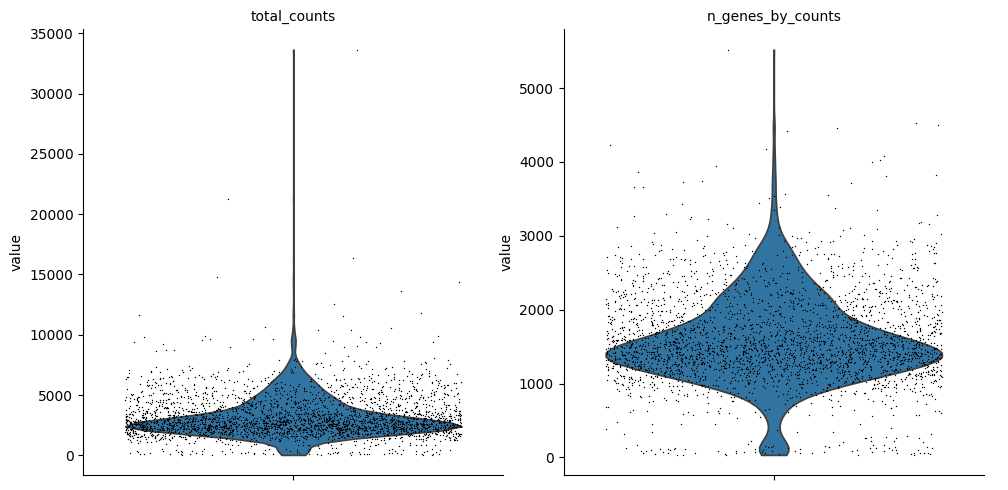

In [23]:
sc.pp.calculate_qc_metrics(adata, inplace=True)
sc.pl.violin(adata, ['total_counts', 'n_genes_by_counts'], jitter=0.4, multi_panel=True)


To prepare the data for downstream analysis, we:
- Filter out low-quality cells and rarely expressed genes.
- Normalize total counts per cell and log-transform.
- Identify highly variable genes, which carry the most biological signal.
- Scale data and perform PCA to reduce dimensionality.

c:\Users\ksgaf\anaconda3\envs\pbmc-env\lib\site-packages\scanpy\preprocessing\_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
c:\Users\ksgaf\anaconda3\envs\pbmc-env\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


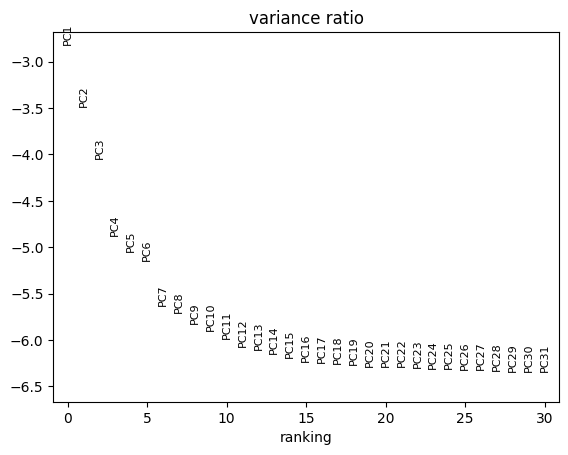

In [24]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, min_mean=0.05, max_mean=2, min_disp=0.75)

adata = adata[:, adata.var.highly_variable]

sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=True)



In [25]:

print(f'{sum(adata.var.highly_variable) / len(adata.var.highly_variable)*100}% of genes are highly variable')

100.0% of genes are highly variable


c:\Users\ksgaf\anaconda3\envs\pbmc-env\lib\site-packages\scanpy\tools\_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
c:\Users\ksgaf\anaconda3\envs\pbmc-env\lib\site-packages\scanpy\tools\_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
c:\Users\ksgaf\anaconda3\envs\pbmc-env\lib\site-packages\scanpy\tools\_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
c:\Users\ksgaf\anaconda3\envs\pbmc-env\lib\site-packages\scanpy\tools\_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
c:\Users\ksgaf\anaconda3\envs\pbmc-env\lib\site-packages\scanpy\tools\_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.l

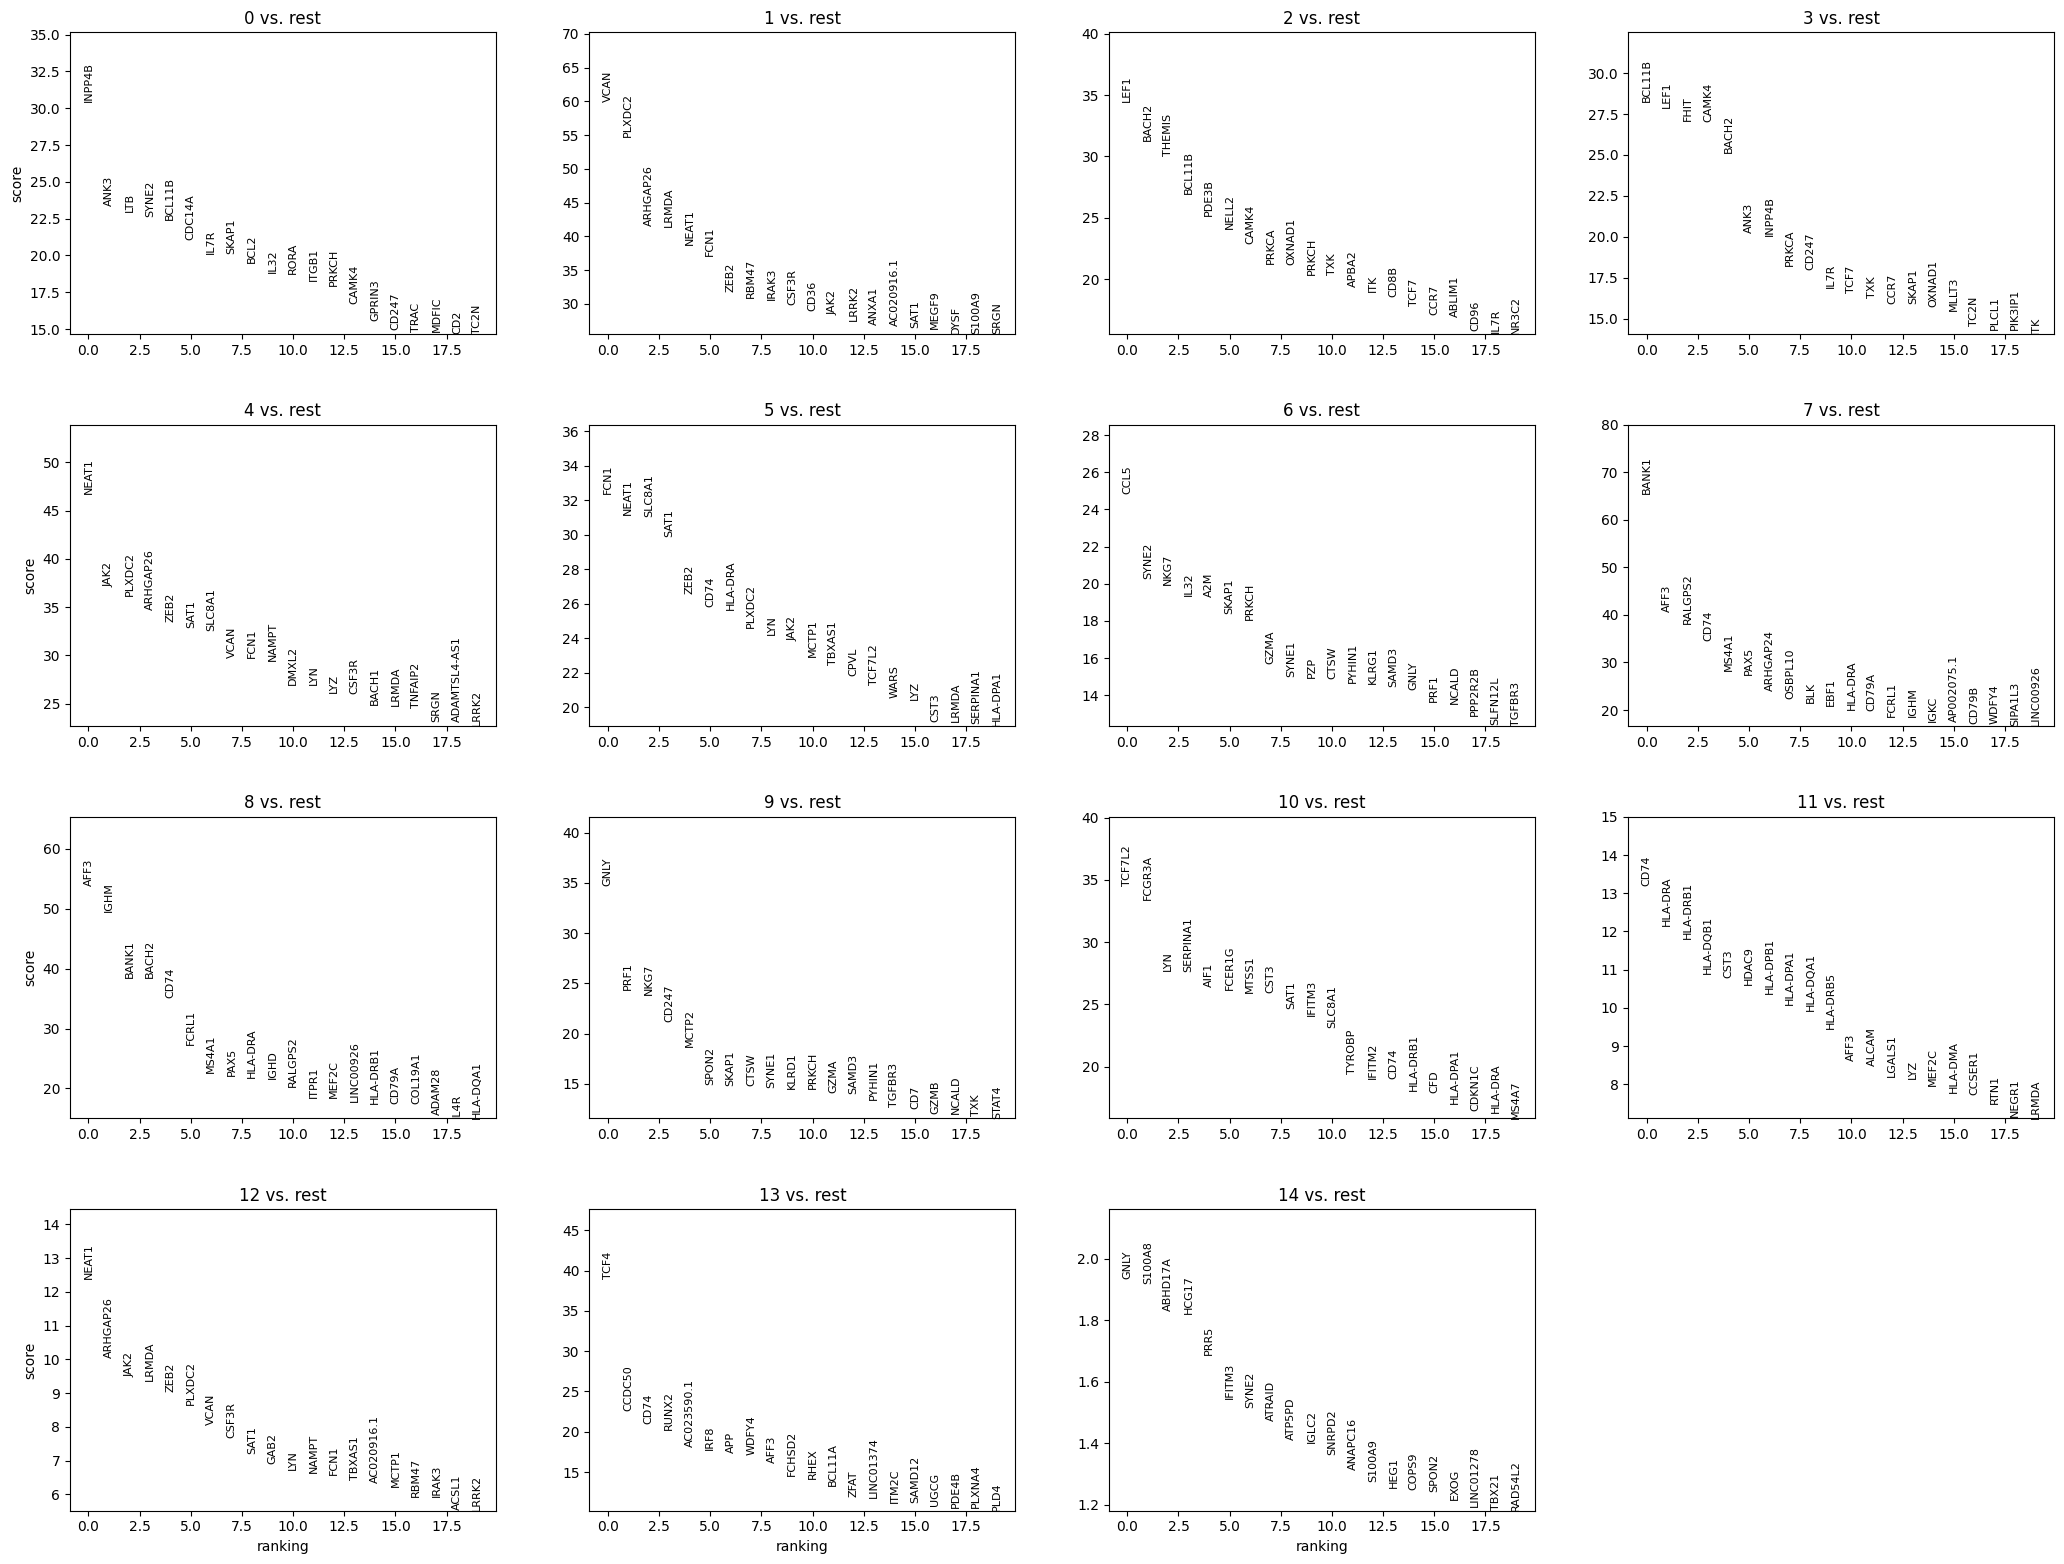

In [27]:
sc.tl.rank_genes_groups(adata, 'leiden', method='t-test')
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)



We build a nearest-neighbors graph and embed the data into 2D using UMAP. We then perform Leiden clustering to identify transcriptionally similar cell populations.

Finally, we plot UMAP colored by cluster (`leiden`) and some example marker genes.


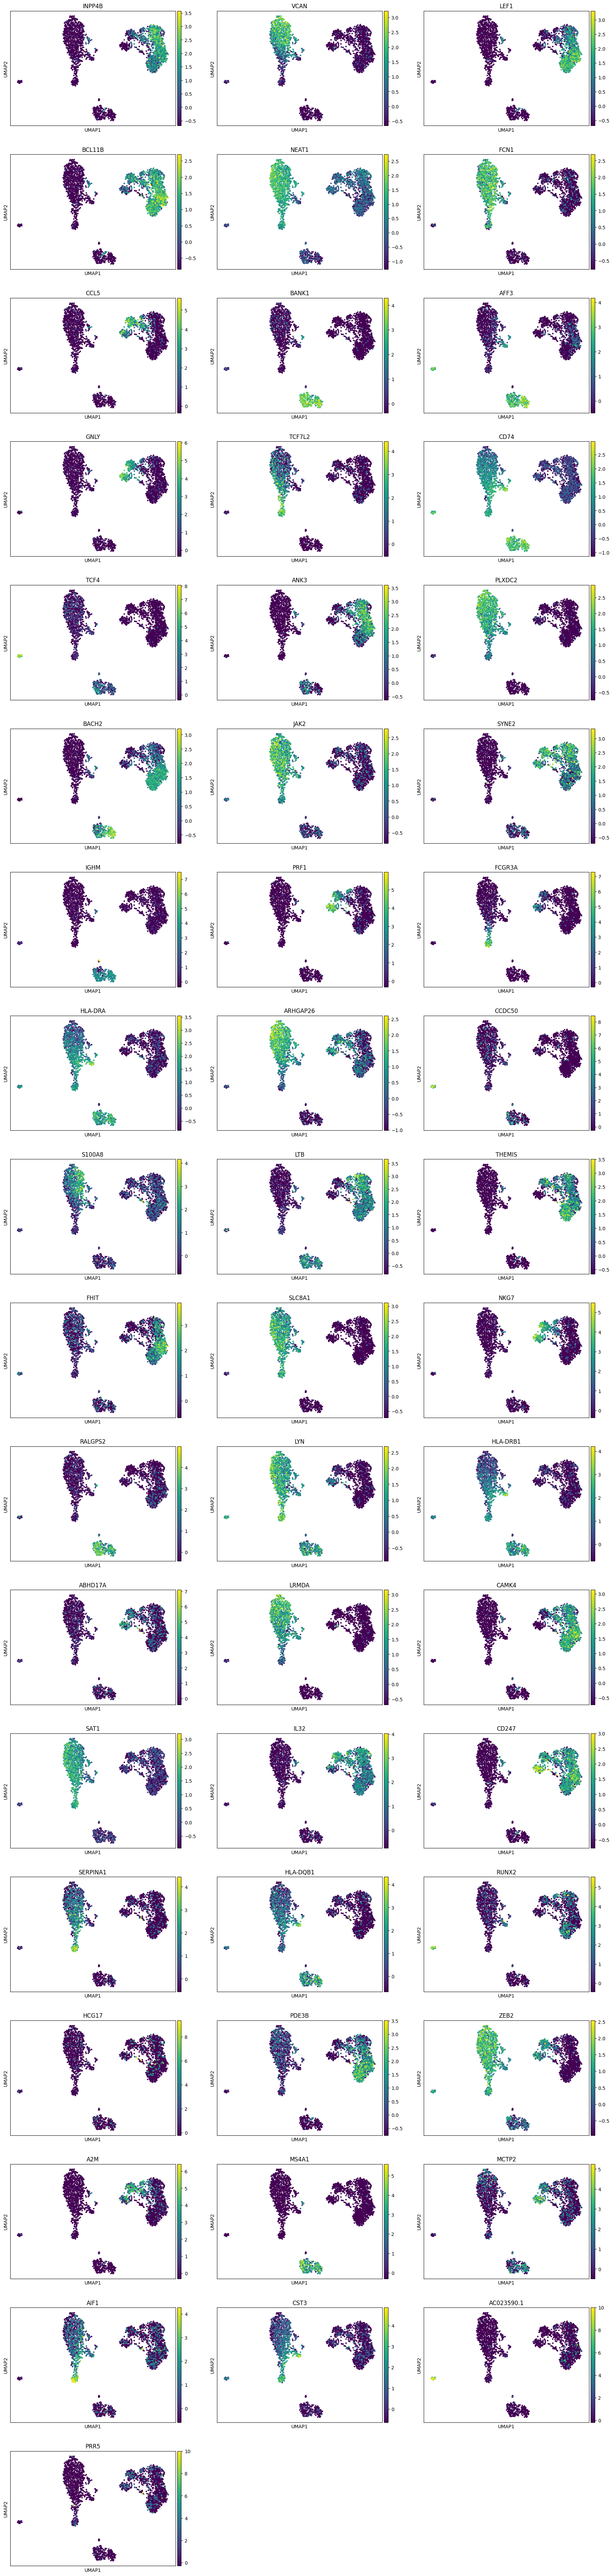

In [28]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)
sc.tl.leiden(adata)

top_genes = adata.uns['rank_genes_groups']['names']
top_genes_df = pd.DataFrame(top_genes).head(5)
top_gene_list = pd.unique(top_genes_df.values.ravel()).tolist()

sc.pl.umap(adata, color=top_gene_list, ncols=3)



In [ ]:
# for 14 clusters, we can visualize the top 5 genes for each cluster
top_genes_df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,INPP4B,VCAN,LEF1,BCL11B,NEAT1,FCN1,CCL5,BANK1,AFF3,GNLY,TCF7L2,CD74,NEAT1,TCF4,GNLY
1,ANK3,PLXDC2,BACH2,LEF1,JAK2,NEAT1,SYNE2,AFF3,IGHM,PRF1,FCGR3A,HLA-DRA,ARHGAP26,CCDC50,S100A8
2,LTB,ARHGAP26,THEMIS,FHIT,PLXDC2,SLC8A1,NKG7,RALGPS2,BANK1,NKG7,LYN,HLA-DRB1,JAK2,CD74,ABHD17A
3,SYNE2,LRMDA,BCL11B,CAMK4,ARHGAP26,SAT1,IL32,CD74,BACH2,CD247,SERPINA1,HLA-DQB1,LRMDA,RUNX2,HCG17
4,BCL11B,NEAT1,PDE3B,BACH2,ZEB2,ZEB2,A2M,MS4A1,CD74,MCTP2,AIF1,CST3,ZEB2,AC023590.1,PRR5



To understand what defines each cluster, we perform differential expression analysis using a t-test. This identifies the top genes per cluster.


Based on marker gene expression and known immune markers, we can assign biological cell types to each cluster.

You can modify the dictionary below based on your marker gene findings.

C:\Users\ksgaf\AppData\Local\Temp\ipykernel_28332\3154051526.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs['cell_type'] = adata.obs['leiden'].replace({


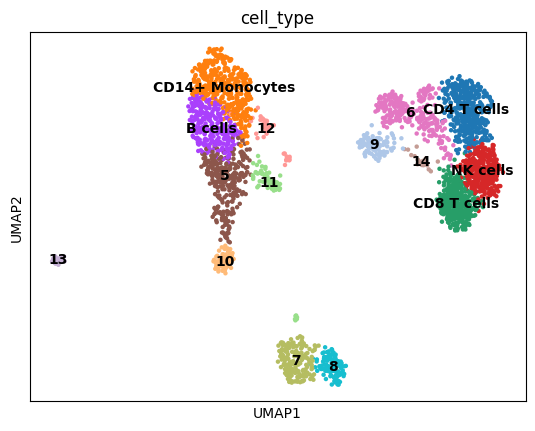

In [33]:
adata.obs['cell_type'] = adata.obs['leiden'].replace({
    '0': 'CD4 T cells',
    '1': 'CD14+ Monocytes',
    '2': 'CD8 T cells',
    '3': 'NK cells',
    '4': 'B cells',
    # Add more as needed based on DE genes
})

sc.pl.umap(adata, color='cell_type', legend_loc='on data')


save the processed `AnnData` object to a `.h5ad` file for later reuse, sharing, or ATAC integration.

In [34]:
os.makedirs("results", exist_ok=True)
adata.write("results/processed_pbmc.h5ad")

